# 1.Importing Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

# List of file paths
file_paths = [
    '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv',
    '/kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv'
]

# Initialize an empty list to hold the dataframes
df_list = []

# Read each CSV file and append it to the list
for path in file_paths:
    df = pd.read_csv(path)
    df_list.append(df)

# Concatenate all dataframes in the list
combined_df = pd.concat(df_list, ignore_index=True)

# Save the combined dataframe to a new CSV file
combined_df.to_csv('/kaggle/working/combined_dataset.csv', index=False)

In [3]:
import pandas as pd

# Load the combined dataset
data = pd.read_csv('/kaggle/working/combined_dataset.csv')

In [4]:

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [5]:
(data.head())
print(data.info())  # Inspect the DataFrame structure


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

# 2. Dataset Prerpocesing

In [6]:
# Check for missing values
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

Flow Bytes/s    1358
dtype: int64


In [7]:
# Analyze target column (e.g., 'Label' for intrusion detection)
data.columns = data.columns.str.strip()
if 'Label' in data.columns:
    print(data['Label'].value_counts())
else:
    print("Column 'Label' not found. Please check the column name.")



Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [8]:
# Check column data types
print(data.dtypes)

# Identify non-numeric columns
non_numeric_columns = data.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)


Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object
Non-numeric columns: Index(['Label'], dtype='object')


In [9]:
# Strip leading and trailing spaces from column names
data.columns = data.columns.str.strip()

# Check if the column names are normalized
print(data.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [10]:
from sklearn.preprocessing import LabelEncoder

# Encode the 'Label' column
label_encoder = LabelEncoder()
data['Label'] = label_encoder.fit_transform(data['Label'])

print("Encoded Labels:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))


Encoded Labels: {'BENIGN': 0, 'Bot': 1, 'DDoS': 2, 'DoS GoldenEye': 3, 'DoS Hulk': 4, 'DoS Slowhttptest': 5, 'DoS slowloris': 6, 'FTP-Patator': 7, 'Heartbleed': 8, 'Infiltration': 9, 'PortScan': 10, 'SSH-Patator': 11, 'Web Attack � Brute Force': 12, 'Web Attack � Sql Injection': 13, 'Web Attack � XSS': 14}


In [11]:
# Compute correlation matrix
correlation_matrix = data.corr()
print(correlation_matrix)


                             Destination Port  Flow Duration  \
Destination Port                     1.000000      -0.151680   
Flow Duration                       -0.151680       1.000000   
Total Fwd Packets                   -0.004236       0.020857   
Total Backward Packets              -0.003947       0.019670   
Total Length of Fwd Packets          0.011145       0.065456   
...                                       ...            ...   
Idle Mean                           -0.112585       0.768034   
Idle Std                             0.010399       0.243154   
Idle Max                            -0.108185       0.779527   
Idle Min                            -0.114614       0.738328   
Label                               -0.078526       0.072592   

                             Total Fwd Packets  Total Backward Packets  \
Destination Port                     -0.004236               -0.003947   
Flow Duration                         0.020857                0.019670   
Total Fwd

In [12]:
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Strip whitespace from column names
data.columns = data.columns.str.strip()

# Step 2: Replace inf/-inf values with NaN
X = data.drop(columns=['Label'])  # Features
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 3: Handle missing values
imputer = SimpleImputer(strategy='mean')  # Impute missing values with mean
X_imputed = imputer.fit_transform(X)  # Fill missing values

# Step 4: Remove constant features
constant_filter = VarianceThreshold(threshold=0.0)  # Remove features with zero variance
X_filtered = constant_filter.fit_transform(X_imputed)

# Get names of non-constant features
non_constant_features = X.columns[constant_filter.get_support()]

# Step 5: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# Step 6: Encode the target column
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Label'])  # Encode the target column

# Step 7: Apply feature selection
selector = SelectKBest(score_func=f_classif, k=10)  # Select top 10 features
X_new = selector.fit_transform(X_scaled, y)

# Retrieve the names of selected features
selected_feature_indices = selector.get_support(indices=True)
selected_features = non_constant_features[selected_feature_indices]  # Use non-constant feature names

# Step 8: Print the selected features
print("Selected Features:", selected_features)


Selected Features: Index(['Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Fwd IAT Std', 'Max Packet Length',
       'Packet Length Std', 'Packet Length Variance', 'Avg Bwd Segment Size',
       'Idle Mean', 'Idle Min'],
      dtype='object')


In [13]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

# Step 1: Strip whitespace from column names
data.columns = data.columns.str.strip()

# Step 2: Replace infinite values with NaN
X = data.drop(columns=['Label'])  # Features
X.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace inf/-inf with NaN

# Step 3: Handle missing values using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Impute missing values with mean
X_imputed = imputer.fit_transform(X)  # Impute and transform the feature matrix

# Step 4: Remove constant features
constant_filter = VarianceThreshold(threshold=0.0)  # Remove constant features
X_filtered = constant_filter.fit_transform(X_imputed)  # Filter constant features

# Get feature names after removing constant features
non_constant_features = X.columns[constant_filter.get_support()]

# Step 5: Encode the target column
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Label'])  # Encode the target column

# Step 6: Apply SelectKBest for feature selection
selector = SelectKBest(score_func=f_classif, k=10)  # Select top 10 features
X_new = selector.fit_transform(X_filtered, y)  # Perform feature selection

# Step 7: Retrieve the names of selected features
selected_feature_indices = selector.get_support(indices=True)
selected_features = non_constant_features[selected_feature_indices]  # Use non-constant feature names

# Step 8: Print the selected features
print("Selected Features:", selected_features)


Selected Features: Index(['Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Fwd IAT Std', 'Max Packet Length',
       'Packet Length Std', 'Packet Length Variance', 'Avg Bwd Segment Size',
       'Idle Mean', 'Idle Min'],
      dtype='object')


# 3. Dataset split defining

In [14]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [15]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# 4. GAN model Defining (ML Model)

In [16]:
import torch
from torch import nn
from torchvision.models import resnet18
from torchvision.transforms import Resize, Normalize, Compose

# Define HybridDiscriminator
class HybridDiscriminator(nn.Module):
    def __init__(self):
        super(HybridDiscriminator, self).__init__()
        self.feature_extractor = resnet18(pretrained=True)
        self.feature_extractor.fc = nn.Identity()  # Remove classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),  # Assuming 512 features from ResNet
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

# Initialize discriminator
discriminator = HybridDiscriminator()

# Example Test Input: Ensure it is resized and normalized
transform = Compose([
    Resize((224, 224)),  # Resize to ResNet input size
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize as per ResNet
])

# Create dummy data (replace with actual data)
dummy_features = torch.randn(1, 3, 224, 224)  # Batch size=1, 3 channels (RGB), 224x224 image

# Apply transformation directly to the tensor
test_input = dummy_features  # No need for `ToTensor()` since it's already a tensor
test_input = transform(test_input)  # Apply resize and normalization

# Test the discriminator
test_output = discriminator(test_input)
print("Discriminator output (should be in [0, 1]):", test_output)

# Generator Class
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Tanh()  # Output scaled between [-1, 1]
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize GAN components
input_dim = 100  # Latent space dimension for generator input
output_dim = 512  # Match output of the generator with ResNet's expected input
generator = Generator(input_dim=input_dim, output_dim=output_dim)

print("GAN initialized")


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 81.6MB/s]


Discriminator output (should be in [0, 1]): tensor([[0.5833]], grad_fn=<SigmoidBackward0>)
GAN initialized


# 5. GAN 1st stage training

In [17]:
import torch
from torch import nn
from torchvision.models import resnet18
from torchvision.transforms import Resize, Normalize, ToTensor, Compose
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Step 1: Define the Generator
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Tanh()  # Output scaled between [-1, 1]
        )

    def forward(self, x):
        return self.model(x)

# Step 2: Define the HybridDiscriminator
class HybridDiscriminator(nn.Module):
    def __init__(self):
        super(HybridDiscriminator, self).__init__()
        self.feature_extractor = resnet18(pretrained=True)
        self.feature_extractor.fc = nn.Identity()  # Remove classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),  # Assuming 512 features from ResNet
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

# Step 3: Initialize GAN components
latent_dim = 100
image_channels = 3
image_height, image_width = 224, 224

generator = Generator(input_dim=latent_dim, output_dim=image_channels * image_height * image_width)
discriminator = HybridDiscriminator()

# Step 4: Transforms for discriminator input
transform = Compose([
    Resize((image_height, image_width)),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Step 5: Prepare synthetic data
num_samples = 1000
num_features = latent_dim  # Matching generator input dimensions
X = np.random.rand(num_samples, num_features).astype(np.float32)
y = np.random.randint(0, 2, size=num_samples)

# Preprocess data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

# Step 6: Initialize optimizers and schedulers
criterion = nn.BCELoss()
gen_optimizer = Adam(generator.parameters(), lr=0.0002)
disc_optimizer = Adam(discriminator.parameters(), lr=0.0002)

gen_scheduler = StepLR(gen_optimizer, step_size=10, gamma=0.5)
disc_scheduler = StepLR(disc_optimizer, step_size=10, gamma=0.5)

# Step 7: Training loop
num_epochs = 10
batch_size = 64
k = 2  # Train discriminator every k steps

for epoch in range(num_epochs):
    for i in range(0, X_train_tensor.shape[0], batch_size):
        # Prepare real data
        real_data = X_train_tensor[i:i + batch_size]
        batch_size_actual = real_data.shape[0]
        
        # Generate synthetic images
        real_data = torch.randn(batch_size_actual, image_channels, image_height, image_width)
        real_data = transform(real_data)
        
        # Generate fake data
        noise = torch.randn(batch_size_actual, latent_dim)
        fake_data = generator(noise).view(batch_size_actual, image_channels, image_height, image_width).detach()

        # Add Gaussian noise to discriminator inputs
        noise_real = torch.randn_like(real_data) * 0.1
        noise_fake = torch.randn_like(fake_data) * 0.1
        
        real_output = discriminator(real_data + noise_real).clamp(0, 1)
        fake_output = discriminator(fake_data + noise_fake).clamp(0, 1)

        # Train Discriminator
        real_labels = torch.ones(batch_size_actual, 1, dtype=torch.float32)
        fake_labels = torch.zeros(batch_size_actual, 1, dtype=torch.float32)

        disc_optimizer.zero_grad()
        real_loss = criterion(real_output, real_labels)
        fake_loss = criterion(fake_output, fake_labels)
        disc_loss = real_loss + fake_loss
        disc_loss.backward()

        if i % k == 0:
            disc_optimizer.step()

        # Train Generator
        gen_optimizer.zero_grad()
        fake_data = generator(noise).view(batch_size_actual, image_channels, image_height, image_width)
        fake_output_for_gen = discriminator(fake_data).clamp(0, 1)
        gen_loss = criterion(fake_output_for_gen, real_labels)
        gen_loss.backward()
        gen_optimizer.step()

    # Step schedulers
    gen_scheduler.step()
    disc_scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Discriminator Loss: {disc_loss.item()}, Generator Loss: {gen_loss.item()}")

print("Training complete.")


Epoch 1/10, Discriminator Loss: 1.0200796127319336, Generator Loss: 1.1408857107162476
Epoch 2/10, Discriminator Loss: 0.5136350393295288, Generator Loss: 1.6081700325012207
Epoch 3/10, Discriminator Loss: 0.23564384877681732, Generator Loss: 2.336179494857788
Epoch 4/10, Discriminator Loss: 0.11051241308450699, Generator Loss: 2.9443044662475586
Epoch 5/10, Discriminator Loss: 0.04662519693374634, Generator Loss: 3.8333449363708496
Epoch 6/10, Discriminator Loss: 0.028799258172512054, Generator Loss: 4.307265758514404
Epoch 7/10, Discriminator Loss: 0.022266488522291183, Generator Loss: 4.444245338439941
Epoch 8/10, Discriminator Loss: 0.015362623147666454, Generator Loss: 4.862689018249512
Epoch 9/10, Discriminator Loss: 0.13483314216136932, Generator Loss: 4.380314826965332
Epoch 10/10, Discriminator Loss: 0.022124024108052254, Generator Loss: 5.211517333984375
Training complete.


#  6. Generate synthetic data

In [18]:
# Generate synthetic data
synthetic_images = generator(torch.randn(1000, latent_dim)).detach().cpu().numpy()  # Generate synthetic image data

# Flatten synthetic images to match tabular data format
synthetic_data_flattened = synthetic_images.reshape(1000, -1)  # Flatten images to 1D feature vectors

# Reduce dimensions of synthetic data to match real data
from sklearn.decomposition import PCA

pca = PCA(n_components=X_train.shape[1])  # Match the number of features in X_train
synthetic_data_reduced = pca.fit_transform(synthetic_data_flattened)

# Check dimensions after PCA
if X_train.shape[1] != synthetic_data_reduced.shape[1]:
    raise ValueError(f"Dimension mismatch after PCA: Real data has {X_train.shape[1]} features, "
                     f"but synthetic data has {synthetic_data_reduced.shape[1]} features.")

# Combine real and synthetic data
combined_data = np.vstack((X_train, synthetic_data_reduced))  # Combine along the 0-axis
combined_data = pd.DataFrame(data=combined_data)  # Convert to pandas DataFrame

print("Synthetic data added to the dataset")


Synthetic data added to the dataset


# 7. Dataset Validation after the adding synthetic data

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('/kaggle/working/combined_dataset.csv')

# Inspect the dataset for column names
print("Dataset columns:", data.columns)

# Replace ' Label' with your actual target column name
target_column = ' Label'  # Adjusted target column name based on provided dataset

# Validate the presence of the target column
if target_column not in data.columns:
    raise ValueError(f"The dataset must contain a column named '{target_column}' for the target variable.")

# Separate features and target
combined_data = data.drop(columns=[target_column])  # Features
y_train = data[target_column]  # Target

# Clean the target column by replacing encoding issues
y_train = y_train.str.replace('�', '-', regex=False)

# Re-inspect the unique labels in the target column after cleaning
unique_labels = y_train.unique()
print("Unique labels in the target column after cleaning:", unique_labels)

# Update the label mapping to include all cleaned labels
label_mapping = {
    'BENIGN': 0,
    'DDoS': 1,
    'PortScan': 2,
    'Bot': 3,
    'Infiltration': 4,
    'Web Attack - Brute Force': 5,
    'Web Attack - XSS': 6,
    'Web Attack - Sql Injection': 7,
    'FTP-Patator': 8,
    'SSH-Patator': 9,
    'DoS slowloris': 10,
    'DoS Slowhttptest': 11,
    'DoS Hulk': 12,
    'DoS GoldenEye': 13,
    'Heartbleed': 14
}

# Attempt to map the cleaned labels
y_train = y_train.map(label_mapping)

# Check for unmapped labels after cleaning
unmapped_labels = unique_labels[~pd.Series(unique_labels).isin(label_mapping.keys())]
if len(unmapped_labels) > 0:
    raise ValueError(f"Some labels in the target column could not be mapped after cleaning: {unmapped_labels}. "
                     f"Please update your label mapping to include these values.")

print("Label mapping completed successfully.")

Dataset columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Le

# 8. Final Training of GAN model

Shape of combined_data: (2830743, 78)
Length of y_train: 2830743


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.9471 - loss: 0.1703 - val_accuracy: 0.9746 - val_loss: 0.0663
Epoch 2/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.9694 - loss: 0.0775 - val_accuracy: 0.9754 - val_loss: 0.0604
Epoch 3/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.9722 - loss: 0.0700 - val_accuracy: 0.9717 - val_loss: 0.0574
Epoch 4/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.9733 - loss: 0.0683 - val_accuracy: 0.9816 - val_loss: 0.0516
Epoch 5/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.9749 - loss: 0.0643 - val_accuracy: 0.9790 - val_loss: 0.0506
Epoch 6/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.9754 - loss: 0.0625 - val_accuracy: 0.9756 - val_loss: 0.0502
Epoch 7/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.9765 - loss: 0.0600 - val_accuracy: 0.9777 - val_loss: 0.0501
Epoch 8/20
28308/28308 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 

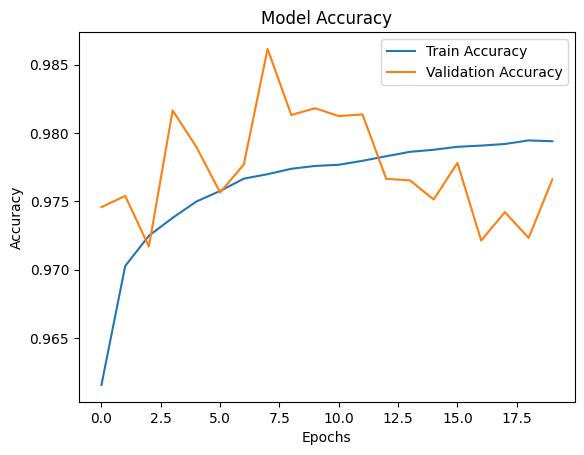

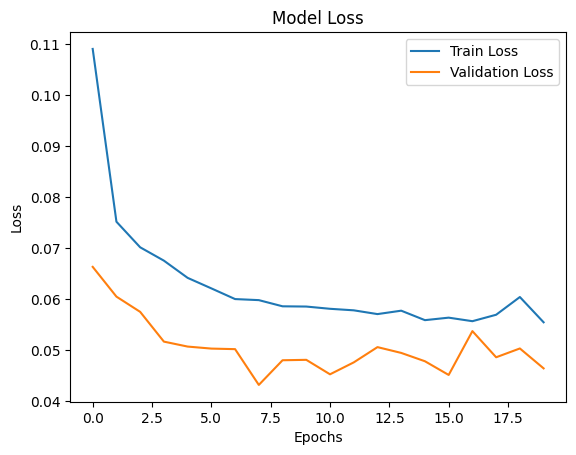

In [20]:
# Ensure combined_data and y_train have the same number of rows
if combined_data.shape[0] > len(y_train):
    combined_data = combined_data[:len(y_train)]
elif len(y_train) > combined_data.shape[0]:
    y_train = y_train[:combined_data.shape[0]]

# Handle problematic values
combined_data.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN
combined_data.fillna(combined_data.mean(), inplace=True)  # Replace NaNs with column means

# Check shapes after alignment
print("Shape of combined_data:", combined_data.shape)
print("Length of y_train:", len(y_train))

# Prepare the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(combined_data)  # Scale the data for better training

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_train, test_size=0.2, random_state=42)

# Define the Keras model
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),  # Input layer
    Dropout(0.5),  # Dropout for regularization
    Dense(32, activation='relu'),  # Hidden layer
    Dense(len(label_mapping), activation='softmax')  # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=64, verbose=1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Model training complete. Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 9. Model Evaluation

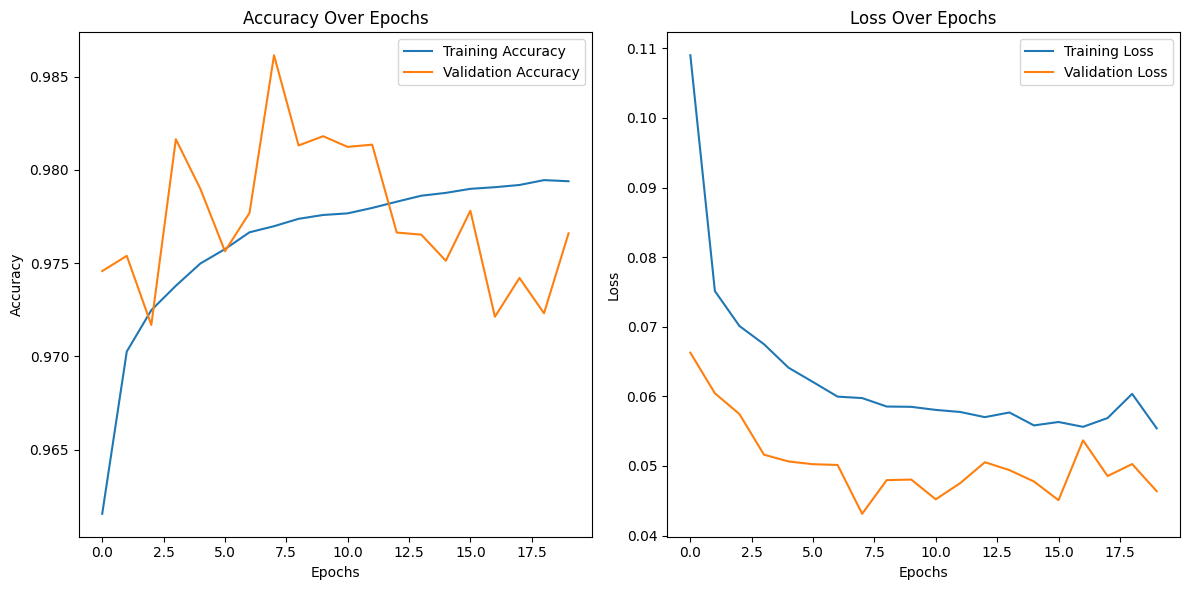

In [21]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


17693/17693 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step
y_pred shape: (566149, 15)
y_test shape: (566149,)


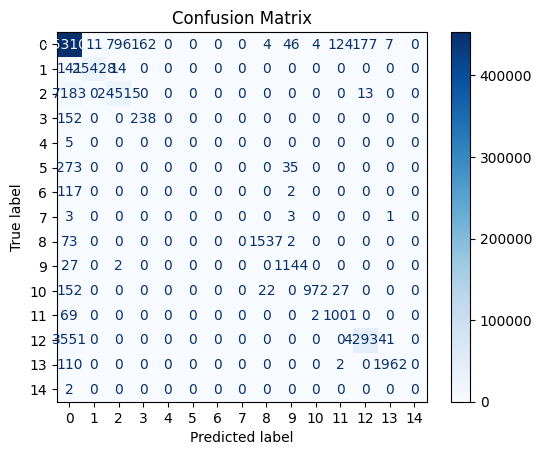

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Generate predictions
y_pred = model.predict(X_test)

# Ensure the predictions match the test set size
print(f"y_pred shape: {y_pred.shape}")
print(f"y_test shape: {y_test.shape}")

if y_pred.shape[0] != y_test.shape[0]:
    raise ValueError("Mismatch in the number of samples between y_pred and y_test.")

# Convert probabilities to class indices for multiclass classification
y_pred_classes = np.argmax(y_pred, axis=1)

# Flatten y_test in case it's multidimensional
y_test_flattened = y_test.ravel()

# Check for consistent length
if len(y_pred_classes) != len(y_test_flattened):
    raise ValueError("y_pred_classes and y_test have inconsistent lengths.")

# Confusion Matrix
cm = confusion_matrix(y_test_flattened, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(y_pred.shape[1]))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()


17693/17693 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step
Unique predictions: [ 0  1  2  3  8  9 10 11 12 13]
Unique true labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


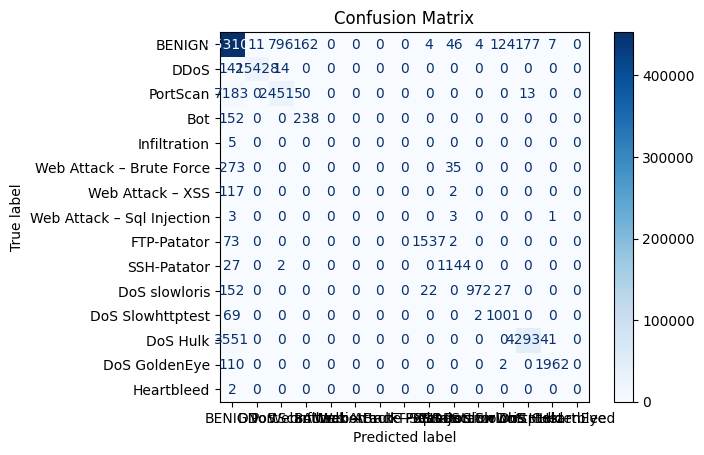

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       0.97      1.00      0.99    454434
                      DDoS       1.00      0.99      1.00     25583
                  PortScan       0.97      0.77      0.86     31711
                       Bot       0.59      0.61      0.60       390
              Infiltration       1.00      0.00      0.00         5
  Web Attack – Brute Force       1.00      0.00      0.00       308
          Web Attack – XSS       1.00      0.00      0.00       119
Web Attack – Sql Injection       1.00      0.00      0.00         7
               FTP-Patator       0.98      0.95      0.97      1612
               SSH-Patator       0.93      0.98      0.95      1173
             DoS slowloris       0.99      0.83      0.90      1173
          DoS Slowhttptest       0.87      0.93      0.90      1072
                  DoS Hulk       1.00      0.92      0.96     46486
             DoS GoldenE

In [23]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = [
    'BENIGN',
    'DDoS',
    'PortScan',
    'Bot',
    'Infiltration',
    'Web Attack – Brute Force',
    'Web Attack – XSS',
    'Web Attack – Sql Injection',
    'FTP-Patator',
    'SSH-Patator',
    'DoS slowloris',
    'DoS Slowhttptest',
    'DoS Hulk',
    'DoS GoldenEye',
    'Heartbleed'
]

# Ensure predictions are aligned with the labels
y_pred_classes = np.argmax(model.predict(X_test), axis=1)  # Multi-class predictions

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Check and report predictions
print(f"Unique predictions: {np.unique(y_pred_classes)}")
print(f"Unique true labels: {np.unique(y_test)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Dynamically adjust class labels for the confusion matrix
active_classes = sorted(np.unique(y_test))
active_labels = [class_labels[i] for i in active_classes]

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=active_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_classes,
        target_names=active_labels,
        zero_division=1,
    )
)


# 10. Model Saving

In [24]:
from tensorflow.keras.models import load_model
import os

# Save the model in HDF5 format
model.save('model.keras')
print("Model saved successfully as 'model.keras'.")

# Verify the file exists
if os.path.exists('model.keras'):
    print("The model file was saved successfully and is present in the directory.")
else:
    print("Error: The model file was not saved.")


Model saved successfully as 'model.keras'.
The model file was saved successfully and is present in the directory.


In [25]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Example data
labels = ['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration', 
          'Web Attack – Brute Force', 'Web Attack – XSS', 
          'Web Attack – Sql Injection', 'FTP-Patator', 'SSH-Patator',
          'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 
          'DoS GoldenEye', 'Heartbleed']

# Create and fit the LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(labels)

# Save the encoder
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)

print("Label encoder saved successfully as 'label_encoder.pkl'.")

# Verify by loading the encoder
with open('label_encoder.pkl', 'rb') as file:
    loaded_label_encoder = pickle.load(file)

# Test the loaded encoder
encoded_labels = loaded_label_encoder.transform(['BENIGN', 'DDoS', 'Infiltration'])
print("Encoded labels:", encoded_labels)
decoded_labels = loaded_label_encoder.inverse_transform(encoded_labels)
print("Decoded labels:", decoded_labels)


Label encoder saved successfully as 'label_encoder.pkl'.
Encoded labels: [0 2 9]
Decoded labels: ['BENIGN' 'DDoS' 'Infiltration']


In [26]:
y_pred[:10]

array([[9.99801159e-01, 3.66211677e-16, 2.61565562e-34, 1.98833994e-04,
        3.50111521e-23, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.26116862e-44, 8.78782293e-41, 2.12678216e-14, 1.64153257e-14,
        2.99406244e-27, 4.86640518e-29, 4.13106963e-38],
       [1.00000000e+00, 7.77947238e-12, 4.06187596e-24, 1.40712900e-10,
        7.07947359e-14, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 3.85873455e-20, 4.76043186e-20,
        2.89500047e-21, 1.30158192e-30, 1.10033046e-17],
       [1.05461440e-05, 2.80296142e-08, 1.69913574e-19, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        5.47041286e-28, 0.00000000e+00, 1.11886742e-15, 5.54326109e-14,
        9.99989390e-01, 2.30128391e-21, 3.80475525e-29],
       [1.00000000e+00, 2.66415695e-10, 6.39954113e-18, 1.02707114e-10,
        1.05869001e-10, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+0

In [27]:
y_test[:10]

746827      0
946912      0
2216843    12
699389      0
1170268     0
800686      0
1434488     0
1968368     0
934343      0
693547      0
Name:  Label, dtype: int64

# 11. Testing of the model development

In [28]:
!pip install scapy

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.0 MB/s eta 0:00:0000:0100:01


In [29]:
import scapy.all as scapy
from scapy.layers.inet import IP, TCP, UDP
import pandas as pd
import time
import numpy as np
from collections import deque, defaultdict

# Global constants and configurations
PACKET_QUEUE_SIZE = 10000  # Maximum packets to retain in memory
BULK_THRESHOLD = 3 * 1500  # Threshold for bulk data in bytes (3 packets of max Ethernet size)

# Global data structures for state management
packet_queue = deque(maxlen=PACKET_QUEUE_SIZE)
flow_statistics = defaultdict(lambda: {
    'total_fwd_packets': 0,
    'total_bwd_packets': 0,
    'total_length_fwd': 0,
    'total_length_bwd': 0,
    'fwd_packet_lengths': [],
    'bwd_packet_lengths': [],
    'flow_start_time': None,
    'flow_end_time': None,
    'flow_iat': [],
    'fwd_iat': [],
    'bwd_iat': [],
    'idle_times': [],
    'fwd_flags': defaultdict(int),
    'bwd_flags': defaultdict(int),
    'fwd_header_length': 0,
    'bwd_header_length': 0,
    'init_win_bytes_fwd': 0,
    'init_win_bytes_bwd': 0,
    'act_data_pkt_fwd': 0,
    'min_seg_size_fwd': float('inf'),
})

def process_packet(packet):
    """
    Processes a single network packet to extract statistics and update flow states.
    """
    try:
        if IP not in packet:
            return

        # Basic packet information
        pkt_time = time.time()
        src_ip = packet[IP].src
        dst_ip = packet[IP].dst
        proto = packet[IP].proto
        length = len(packet)
        flow_key = (src_ip, dst_ip, proto)

        # Determine direction
        direction = 'fwd' if src_ip < dst_ip else 'bwd'

        # Initialize flow start time
        if flow_statistics[flow_key]['flow_start_time'] is None:
            flow_statistics[flow_key]['flow_start_time'] = pkt_time

        # Update idle time
        if flow_statistics[flow_key]['flow_end_time'] is not None:
            idle_time = pkt_time - flow_statistics[flow_key]['flow_end_time']
            flow_statistics[flow_key]['idle_times'].append(idle_time)

        flow_statistics[flow_key]['flow_end_time'] = pkt_time
        flow_statistics[flow_key][f'total_{direction}_packets'] += 1
        flow_statistics[flow_key][f'total_length_{direction}'] += length
        flow_statistics[flow_key][f'{direction}_packet_lengths'].append(length)
        flow_statistics[flow_key][f'{direction}_iat'].append(pkt_time)

        # TCP-specific processing
        if TCP in packet:
            tcp_layer = packet[TCP]
            flags = tcp_layer.flags
            flow_statistics[flow_key][f'{direction}_flags']['FIN'] += bool(flags.F)
            flow_statistics[flow_key][f'{direction}_flags']['SYN'] += bool(flags.S)
            flow_statistics[flow_key][f'{direction}_flags']['RST'] += bool(flags.R)
            flow_statistics[flow_key][f'{direction}_flags']['PSH'] += bool(flags.P)
            flow_statistics[flow_key][f'{direction}_flags']['ACK'] += bool(flags.A)
            flow_statistics[flow_key][f'{direction}_flags']['URG'] += bool(flags.U)
            flow_statistics[flow_key]['act_data_pkt_fwd'] += 1
            flow_statistics[flow_key]['min_seg_size_fwd'] = min(
                flow_statistics[flow_key]['min_seg_size_fwd'], tcp_layer.window
            )

    except Exception as e:
        print(f"Error processing packet: {e}")


def extract_features(flow_key, stats):
    """
    Extract features from flow statistics for a given flow key.
    """
    try:
        flow_duration = stats['flow_end_time'] - stats['flow_start_time']
        total_fwd_packets = stats['total_fwd_packets']
        total_bwd_packets = stats['total_bwd_packets']

        # Calculate basic flow features
        features = {
            'Flow Duration': flow_duration,
            'Total Fwd Packets': total_fwd_packets,
            'Total Backward Packets': total_bwd_packets,
            'Total Length of Fwd Packets': stats['total_length_fwd'],
            'Total Length of Bwd Packets': stats['total_length_bwd'],
            'Flow Bytes/s': (stats['total_length_fwd'] + stats['total_length_bwd']) / flow_duration if flow_duration > 0 else 0,
            'Flow Packets/s': (total_fwd_packets + total_bwd_packets) / flow_duration if flow_duration > 0 else 0,
            # Add additional derived features as required
        }

        return features

    except Exception as e:
        print(f"Error extracting features for flow {flow_key}: {e}")
        return {}


def start_sniffing(interface):
    """
    Start capturing packets on the specified network interface.
    """
    try:
        print(f"Starting packet capture on {interface}...")
        scapy.sniff(iface=interface, prn=process_packet)
    except Exception as e:
        print(f"Error starting sniffing: {e}")

if __name__ == "__main__":
    # Specify the interface to sniff packets 
    start_sniffing("eth0")


Starting packet capture on eth0...


# 12. Finalize the model with saving

In [30]:
from tensorflow.keras.models import load_model

# Save the model in HDF5 format
model.save('model.keras')